<div>
    <h1 align="center"> MRI Classification</h1>
    <h5 align="center"> Seyyed Hossein Hosseini</h5>
</div>

## Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [2]:
!pip install pydicom

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 27.8 MB/s eta 0:00:00


In [ ]:
!pip install split-folders[full]

In [ ]:
!pip install -U gdown

In [ ]:
pip install tensorflow==2.15.0

In [6]:
import gdown
import os
import glob
import pydicom
import pandas as pd
import shutil
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
sns.set(style="whitegrid")
sns.set_context("paper")
import tensorflow as tf
import random as python_random
from tensorflow.keras import layers
#from tensorflow.keras.layers.experimental.preprocessing import CenterCrop
from scipy import ndimage
import splitfolders

from tensorflow.keras.models import Model
from tensorflow.keras import layers
from tensorflow.keras.layers import Input, Dense, Conv2D, MaxPool2D, Dropout, Flatten, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras import regularizers
from tensorflow.keras.constraints import max_norm
from collections import defaultdict
from tensorflow.keras.callbacks import ModelCheckpoint,EarlyStopping # for saving best model
from tensorflow.keras.metrics import AUC
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

# obtaining reproducible results
SEED = 2024
os.environ['PYTHONHASHSEED'] = str(SEED)
# The below is necessary for starting Numpy generated random numbers
np.random.seed(SEED)
# The below is necessary for starting core Python generated random numbers
python_random.seed(SEED)
tf.random.set_seed(SEED)

In [7]:
print(tf.__version__)

2.15.0


In [ ]:
!python --version

Python 3.10.12


CPU

In [ ]:
# default strategy works on CPU
strategy = tf.distribute.get_strategy()
print('Running on CPU')
print("Number of accelerators: ", strategy.num_replicas_in_sync)

Running on CPU
Number of accelerators:  1


GPU

In [ ]:
print(tf.config.list_physical_devices('GPU'))

[]


In [ ]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


TPU

In [ ]:
# checking that we can connect to TPU
# detecting TPU
try:
  tpu = tf.distribute.cluster_resolver.TPUClusterResolver()
  print('Running on TPU ', tpu.cluster_spec().as_dict()['worker'])
except ValueError: # If TPU not found
  raise BaseException('ERROR: Not connected to a TPU runtime.')

# TPU is a distributed training processor and is not single-core like a traditional CPU
# Selecting appropriate distribution strategy
tf.config.experimental_connect_to_cluster(tpu)
# TPU initialization has to be at the beginning.
tf.tpu.experimental.initialize_tpu_system(tpu)
print("All devices: ", tf.config.list_logical_devices('TPU'))

tpu_strategy = tf.distribute.TPUStrategy(tpu)
print("Number of accelerators: ", tpu_strategy.num_replicas_in_sync)

Running on TPU  ['10.27.176.26:8470']
All devices:  [LogicalDevice(name='/job:worker/replica:0/task:0/device:TPU:0', device_type='TPU'), LogicalDevice(name='/job:worker/replica:0/task:0/device:TPU:1', device_type='TPU'), LogicalDevice(name='/job:worker/replica:0/task:0/device:TPU:2', device_type='TPU'), LogicalDevice(name='/job:worker/replica:0/task:0/device:TPU:3', device_type='TPU'), LogicalDevice(name='/job:worker/replica:0/task:0/device:TPU:4', device_type='TPU'), LogicalDevice(name='/job:worker/replica:0/task:0/device:TPU:5', device_type='TPU'), LogicalDevice(name='/job:worker/replica:0/task:0/device:TPU:6', device_type='TPU'), LogicalDevice(name='/job:worker/replica:0/task:0/device:TPU:7', device_type='TPU')]
Number of accelerators:  8


## Preprocessing

In [ ]:
# downloading data
!gdown 1Z67yKzNNqaXfa0UglcodL5Q3L0pMN-dt

Downloading...
From (original): https://drive.google.com/uc?id=1Z67yKzNNqaXfa0UglcodL5Q3L0pMN-dt
From (redirected): https://drive.google.com/uc?id=1Z67yKzNNqaXfa0UglcodL5Q3L0pMN-dt&confirm=t&uuid=676203a7-9065-4487-ba78-633b9ffb39b6
To: /content/iaaa-mri-train.zip
100% 2.46G/2.46G [00:45<00:00, 54.0MB/s]


In [ ]:
# inflating the 'data' directory with the unzipped files
!unzip /content/iaaa-mri-train.zip -d /content/drive/MyDrive/Projects/MRI/mri_data

In [ ]:
#  number of directories + 1
!find /content/drive/MyDrive/Projects/MRI/mri_data/data -type d | wc -l

3133


In [ ]:
# creating 'DICOM_Data' folder
os.mkdir('/content/drive/MyDrive/Projects/MRI/mri_data/DICOM_Data')
# creating 2 folders in 'DICOM_Data' folder: one for normal and another for abnormal class
os.mkdir('/content/drive/MyDrive/Projects/MRI/mri_data/DICOM_Data/normal')
os.mkdir('/content/drive/MyDrive/Projects/MRI/mri_data/DICOM_Data/abnormal')

In [ ]:
dcm_dir = '/content/drive/MyDrive/Projects/MRI/mri_data/data/'
label_dir = '/content/drive/MyDrive/Projects/MRI/mri_data/train.csv'

In [ ]:
df = pd.read_csv(label_dir)
print(df.shape)
print(df.prediction.unique())
df.head()

(3132, 2)
[0 1]


,SeriesInstanceUID,prediction
0,1.3.46.670589.11.10042.5.0.6048.20240307143704...,0
1,1.3.46.670589.11.10042.5.0.6048.20240307143746...,0
2,1.3.46.670589.11.10042.5.0.6048.20240307143846...,0
3,1.3.46.670589.11.10042.5.0.4776.20240217030800...,0
4,1.3.46.670589.11.10042.5.0.4776.20240217030846...,0


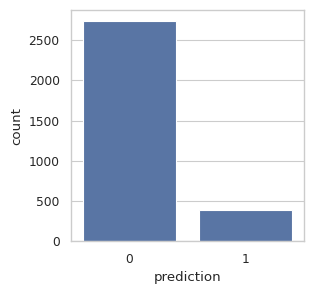

In [ ]:
plt.figure(figsize = (3, 3))
sns.countplot(x = df['prediction']);

In [ ]:
a = df[df['SeriesInstanceUID']=='1.3.46.670589.11.10042.5.0.4776.2024021703084695456'].index.values
print(a)
df.iloc[a[0], 1]

[4]


0

In [ ]:
# Transfering directories from data folder to 'normal' and 'abnormal' folders
directory_names = os.listdir(dcm_dir)
# fetching all directories
for f in directory_names:
    r = df[df['SeriesInstanceUID']==f].index.values
    source = dcm_dir+f
    if df.iloc[r[0], 1] == 0:
        # transfering normal folders to normal folder
        shutil.move(source, '/content/drive/MyDrive/Projects/MRI/mri_data/DICOM_Data/normal')
    else:
        # transfering abnormal folders to abnormal folder
        shutil.move(source, '/content/drive/MyDrive/Projects/MRI/mri_data/DICOM_Data/abnormal')

In [ ]:
# Verify the move
abnormal_directory = '/content/drive/MyDrive/Projects/MRI/mri_data/DICOM_Data/abnormal'
normal_directory = '/content/drive/MyDrive/Projects/MRI/mri_data/DICOM_Data/normal'

# class-imbalanced dataset
print(f"Number of normal samples : {len(os.listdir(normal_directory))}")
print(f"Number of abnormal samples: {len(os.listdir(abnormal_directory))}")

Number of normal samples : 2741
Number of abnormal samples: 391


### Data Visualization

In [ ]:
# this returns a 'list' in specified pattern
# for example
trn_normal_names = glob.glob('/content/drive/MyDrive/Projects/MRI/mri_data/DICOM_Data/normal/1.3.46.670589.11.10042.5.0.1412.2024020321541276410/*.dcm')
print(trn_normal_names[:2])
trn_abnormal_names = glob.glob('/content/drive/MyDrive/Projects/MRI/mri_data/DICOM_Data/abnormal/1.3.46.670589.11.10042.5.0.1412.2024020313391873234/*.dcm')
print(trn_abnormal_names[:2])

['/content/drive/MyDrive/Projects/MRI/mri_data/DICOM_Data/normal/1.3.46.670589.11.10042.5.0.1412.2024020321541276410/1.3.46.670589.11.10042.5.0.1412.2024020321545276419.dcm', '/content/drive/MyDrive/Projects/MRI/mri_data/DICOM_Data/normal/1.3.46.670589.11.10042.5.0.1412.2024020321541276410/1.3.46.670589.11.10042.5.0.1412.2024020321545342432.dcm']
['/content/drive/MyDrive/Projects/MRI/mri_data/DICOM_Data/abnormal/1.3.46.670589.11.10042.5.0.1412.2024020313391873234/1.3.46.670589.11.10042.5.0.1412.2024020313401453257.dcm', '/content/drive/MyDrive/Projects/MRI/mri_data/DICOM_Data/abnormal/1.3.46.670589.11.10042.5.0.1412.2024020313391873234/1.3.46.670589.11.10042.5.0.1412.2024020313401415247.dcm']


In [ ]:
# investigating a single slice
file_path = trn_abnormal_names[0]
dcm_image = pydicom.dcmread(file_path)
print(dcm_image)

Dataset.file_meta -------------------------------
(0002, 0000) File Meta Information Group Length  UL: 212
(0002, 0001) File Meta Information Version       OB: b'\x00\x01'
(0002, 0002) Media Storage SOP Class UID         UI: MR Image Storage
(0002, 0003) Media Storage SOP Instance UID      UI: 1.2.826.0.1.3680043.8.498.90639842786170590251795248383963378547
(0002, 0010) Transfer Syntax UID                 UI: RLE Lossless
(0002, 0012) Implementation Class UID            UI: 1.3.6.1.4.1.30071.8
(0002, 0013) Implementation Version Name         SH: 'fo-dicom 5.1.1'
(0002, 0016) Source Application Entity Title     AE: 'ACHIVA'
-------------------------------------------------
(0008, 0005) Specific Character Set              CS: 'ISO_IR 100'
(0008, 0008) Image Type                          CS: ['ORIGINAL', 'PRIMARY', 'M_SE', 'M', 'SE']
(0008, 0012) Instance Creation Date              DA: '20240203'
(0008, 0013) Instance Creation Time              TM: '135228'
(0008, 0014) Instance Creator U

In [ ]:
dir(dcm_image)

['AccessionNumber',
 'AcquisitionDate',
 'AcquisitionDuration',
 'AcquisitionMatrix',
 'AcquisitionNumber',
 'AcquisitionTime',
 'AdmittingDiagnosesDescription',
 'BitsAllocated',
 'BitsStored',
 'BodyPartExamined',
 'CodeMeaning',
 'CodeValue',
 'CodingSchemeDesignator',
 'Columns',
 'CommentsOnThePerformedProcedureStep',
 'ContentDate',
 'ContentTime',
 'DeidentificationMethodCodeSequence',
 'DeviceSerialNumber',
 'DiffusionBValue',
 'DiffusionGradientOrientation',
 'EchoNumbers',
 'EchoTime',
 'EchoTrainLength',
 'FilmConsumptionSequence',
 'FlipAngle',
 'FrameOfReferenceUID',
 'HeartRate',
 'HighBit',
 'HighRRValue',
 'ImageOrientationPatient',
 'ImagePositionPatient',
 'ImageType',
 'ImagedNucleus',
 'ImagingFrequency',
 'InPlanePhaseEncodingDirection',
 'InstanceCreationDate',
 'InstanceCreationTime',
 'InstanceCreatorUID',
 'InstanceNumber',
 'InstitutionName',
 'InstitutionalDepartmentName',
 'IntervalsAcquired',
 'IntervalsRejected',
 'LossyImageCompression',
 'LowRRValue',
 '

In [ ]:
print(type(dcm_image))
print(dcm_image.SeriesInstanceUID)
print(dcm_image.InstanceNumber)
print(dcm_image.SliceLocation)
print(dcm_image.WindowCenter)
print(dcm_image.WindowWidth)
image = dcm_image.pixel_array
print(image.shape)
print(type(image))
print(image.dtype)

<class 'pydicom.dataset.FileDataset'>
1.3.46.670589.11.10042.5.0.1412.2024020313391873234
1
115.332493146281
313.19
544.59
(288, 288)
<class 'numpy.ndarray'>
uint16


In [ ]:
image

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint16)

In [ ]:
print(image.min())
print(image.max())

0
611


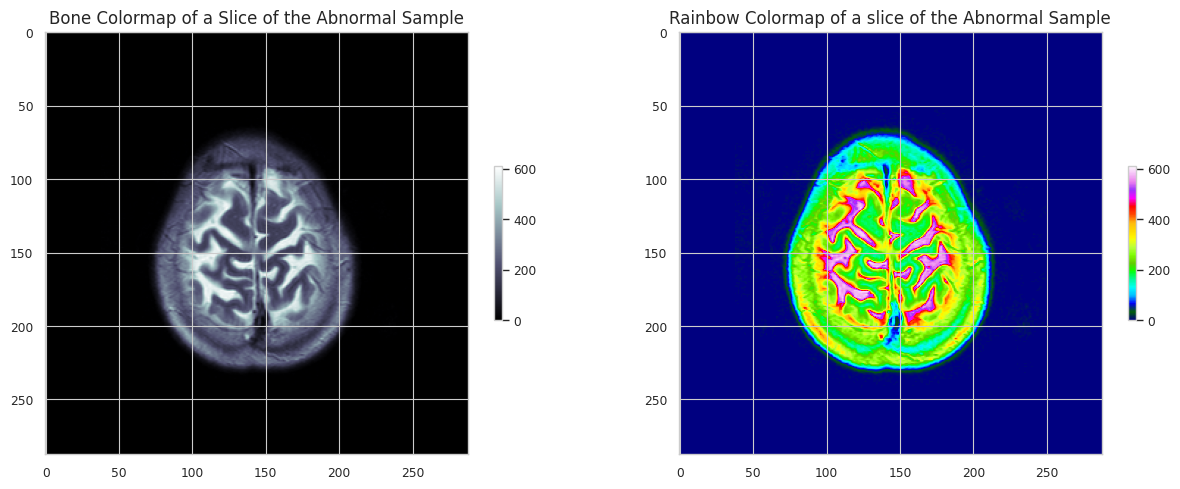

In [ ]:
# visualizing a slice of the abnormal sample by two different colormaps
plt.figure(figsize = (15, 10))
plt.subplot(1, 2, 1)
plt.imshow(image, cmap='bone')
plt.colorbar(shrink=0.2)
plt.title("Bone Colormap of a Slice of the Abnormal Sample", fontsize=12)

plt.subplot(1, 2, 2)
# rainbow colormap to fully utilize computer's ability to display colors
plt.imshow(image, cmap=plt.cm.gist_ncar)
plt.colorbar(shrink=0.2)
plt.title("Rainbow Colormap of a slice of the Abnormal Sample", fontsize=12);

(array([6.4114e+04, 5.1400e+02, 4.3000e+02, 3.5300e+02, 3.3600e+02,
        2.5200e+02, 2.1300e+02, 2.1400e+02, 2.1700e+02, 2.7200e+02,
        3.0500e+02, 3.4700e+02, 4.9700e+02, 7.4700e+02, 9.4100e+02,
        9.1400e+02, 8.5000e+02, 8.2700e+02, 8.5400e+02, 8.5600e+02,
        8.9200e+02, 8.5900e+02, 7.9200e+02, 6.7600e+02, 5.7100e+02,
        4.8800e+02, 4.3500e+02, 3.6700e+02, 3.3300e+02, 2.9100e+02,
        2.8000e+02, 2.5500e+02, 1.7900e+02, 1.9800e+02, 1.5400e+02,
        1.5900e+02, 1.5200e+02, 1.5200e+02, 1.2400e+02, 1.3200e+02,
        1.3000e+02, 1.2800e+02, 1.5800e+02, 1.8500e+02, 1.8400e+02,
        2.4200e+02, 2.2500e+02, 1.0400e+02, 3.8000e+01, 8.0000e+00]),
 array([  0.  ,  12.22,  24.44,  36.66,  48.88,  61.1 ,  73.32,  85.54,
         97.76, 109.98, 122.2 , 134.42, 146.64, 158.86, 171.08, 183.3 ,
        195.52, 207.74, 219.96, 232.18, 244.4 , 256.62, 268.84, 281.06,
        293.28, 305.5 , 317.72, 329.94, 342.16, 354.38, 366.6 , 378.82,
        391.04, 403.26, 415.48

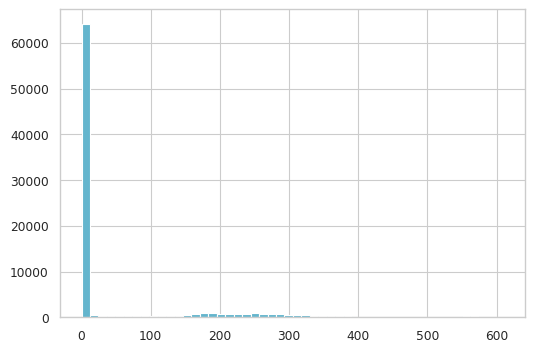

In [ ]:
# plotting histogram
plt.figure(figsize=(6,4))
plt.hist(image.flatten(), bins=50, color='c')

In [ ]:
len(np.unique(image))

605

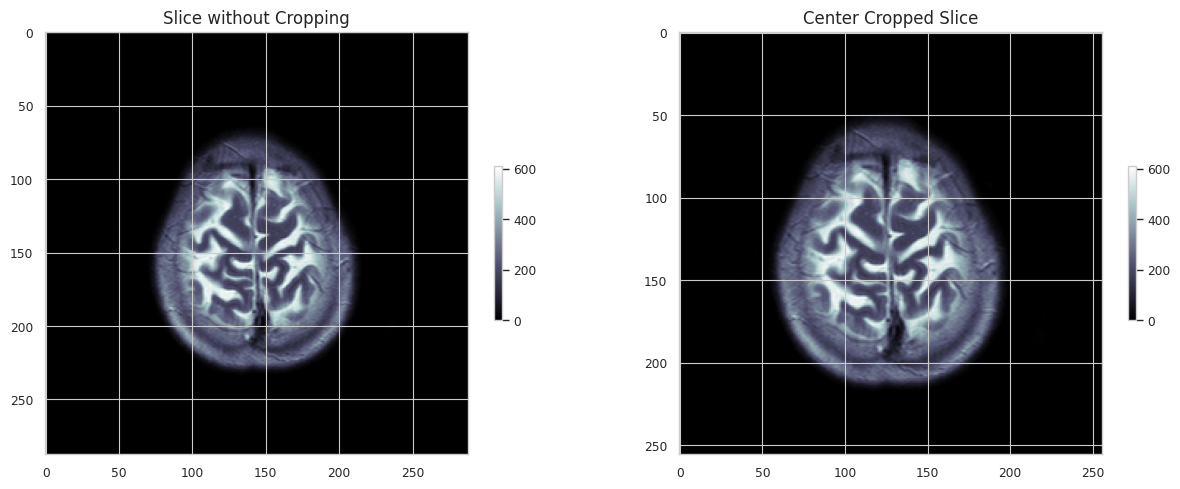

In [ ]:
# cropping the slice
# first method: using Keras layer
#cropper = CenterCrop(height=256, width=256)
# input shape of CenterCrop should be 3D (unbatched) or 4D (batched) tensor
#image2 = np.expand_dims(image, axis=-1)
#cropped_image = cropper(image2)

# second method
width = 256
height = 256
y, x = image.shape
startx = x//2 - (width//2)
starty = y//2 - (height//2)
cropped_image = image[starty:starty+height, startx:startx+width]

plt.figure(figsize = (15, 10))
plt.subplot(1, 2, 1)
plt.imshow(image, cmap='bone')
plt.colorbar(shrink=0.2)
plt.title("Slice without Cropping", fontsize=12)


plt.subplot(1, 2, 2)
plt.imshow(cropped_image, cmap='bone')
plt.colorbar(shrink=0.2)
plt.title("Center Cropped Slice", fontsize=12);

In [ ]:
print(cropped_image.shape)
print(f'Number of unique value: {len(np.unique(cropped_image))}')
print(type(cropped_image))
print(cropped_image.dtype)

(256, 256)
Number of unique value: 605
<class 'numpy.ndarray'>
uint16


(128, 128)
Number of unique value: 580
<class 'numpy.ndarray'>
uint16


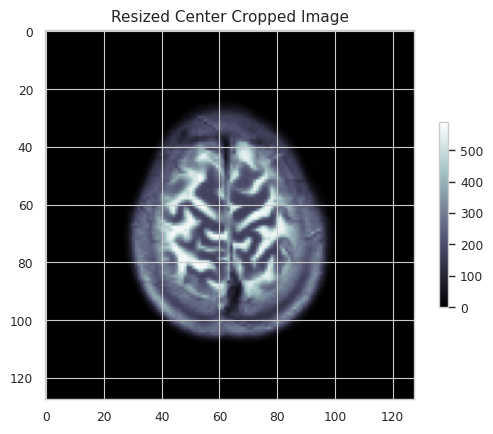

In [ ]:
# Resizing the image
resized_img = ndimage.zoom(cropped_image, (0.5, 0.5), order=1)

print(resized_img.shape)
print(f'Number of unique value: {len(np.unique(resized_img))}')
print(type(resized_img))
print(resized_img.dtype)

plt.imshow(resized_img, cmap='bone')
plt.colorbar(shrink=0.5)
plt.title("Resized Center Cropped Image", fontsize=11);

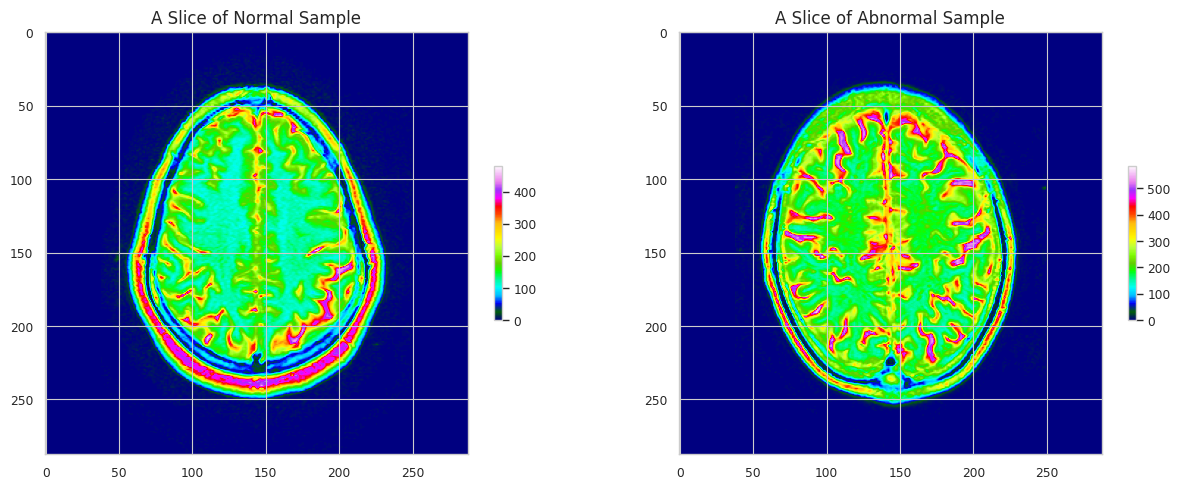

In [ ]:
# normal slice vs abnormal slice

# normal
normal_file_path = trn_normal_names[9]
normal_image = pydicom.dcmread(normal_file_path)
n_image = normal_image.pixel_array

# abnormal
abnormal_file_path = trn_abnormal_names[9]
abnormal_image = pydicom.dcmread(abnormal_file_path)
a_image = abnormal_image.pixel_array

plt.figure(figsize = (15, 10))
plt.subplot(1, 2, 1)
plt.imshow(n_image, cmap=plt.cm.gist_ncar)
plt.colorbar(shrink=0.2)
plt.title("A Slice of Normal Sample", fontsize=12)

plt.subplot(1, 2, 2)
plt.imshow(a_image, cmap=plt.cm.gist_ncar)
plt.colorbar(shrink=0.2)
plt.title("A Slice of Abnormal Sample", fontsize=12);

Combining the pixel arrays of multiple DICOM images into a single NumPy array

In [ ]:
def load_scan(path):
    slices = [pydicom.dcmread(path + '/' + s) for s in os.listdir(path)]
    slices.sort(key = lambda x: int(x.InstanceNumber))
    return slices

In [ ]:
def get_pixels(scans):
    image = np.stack([s.pixel_array for s in scans])
    image = image.astype(np.int16)
    return image

In [ ]:
# for example
path = '/content/drive/MyDrive/Projects/MRI/mri_data/DICOM_Data/abnormal/1.3.46.670589.11.10042.5.0.920.2024010300252204460'
scans = load_scan(path)
dcm_array = get_pixels(scans)
print(dcm_array.shape)
print(type(dcm_array))
print(dcm_array.dtype)
print(dcm_array.max())
print(dcm_array.min())

(18, 288, 288)
<class 'numpy.ndarray'>
int16
473
0


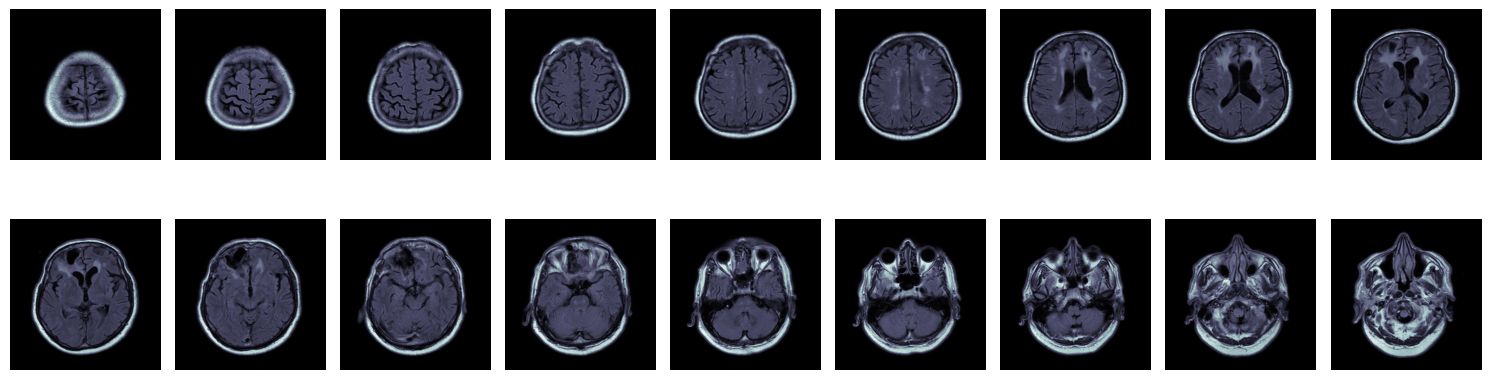

In [ ]:
# Visualizing different slices of an MRI sample
# 'dcm_array' is a 3D numpy array where the first dimension represents number of different slices of an MRI sample
num_images = dcm_array.shape[0]
rows = 2
cols = num_images // 2 + num_images % 2

fig, axs = plt.subplots(rows, cols, figsize=(15, 5))
for idx, img in enumerate(dcm_array):
    row = idx // cols
    col = idx % cols
    axs[row, col].imshow(img, cmap='bone')
    axs[row, col].axis('off')

# Remove any unused subplots
for idx in range(num_images, rows * cols):
    fig.delaxes(axs[idx // cols, idx % cols])

plt.tight_layout() #The tight_layout function ensures that the subplots are properly spaced.
plt.show()

In [ ]:

def center_crop(image, width, height):
    """Center crop of image"""
    y = image.shape[1]
    x = image.shape[2]
    startx = x//2 - (width//2)
    starty = y//2 - (height//2)
    cropped_image = image[:, starty:starty+height, startx:startx+width]
    return cropped_image

In [ ]:
cropped_dcm_array = center_crop(dcm_array, 256, 256)

In [ ]:
cropped_dcm_array.shape

(18, 256, 256)

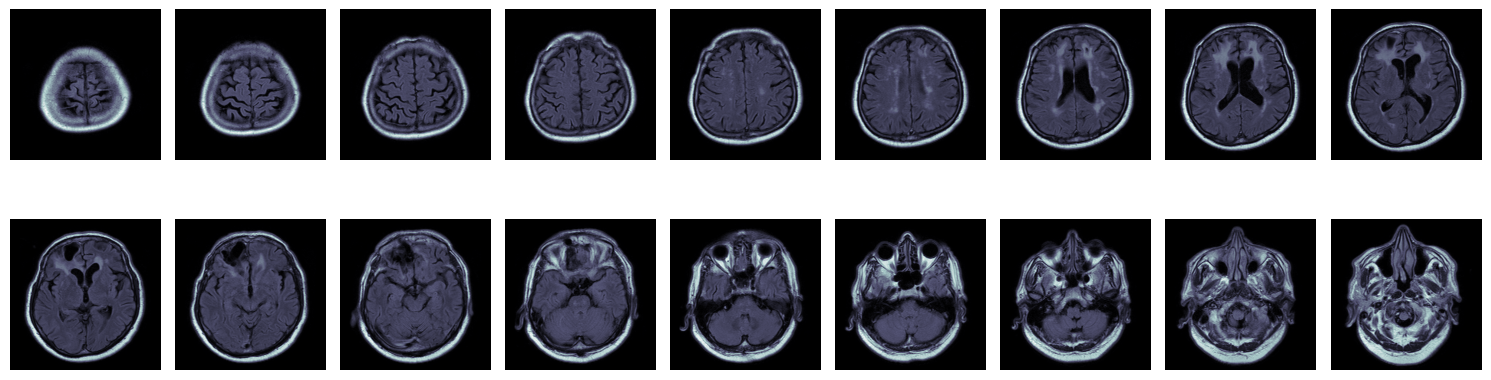

In [ ]:
# visualizing center cropped slices of an MRI sample
num_images = cropped_dcm_array.shape[0]
rows = 2
cols = num_images // 2 + num_images % 2

fig, axs = plt.subplots(rows, cols, figsize=(15, 5))

for idx, img in enumerate(cropped_dcm_array):
    row = idx // cols
    col = idx % cols
    axs[row, col].imshow(img, cmap='bone')
    axs[row, col].axis('off')

# Remove any unused subplots
for idx in range(num_images, rows * cols):
    fig.delaxes(axs[idx // cols, idx % cols])

plt.tight_layout() #The tight_layout function ensures that the subplots are properly spaced.
plt.show()

In [ ]:
# Normalize the array
def normalize(array):
    # normalized_array = array / array.max()
    # Min-Max normalization
    normalized_array = (array - array.min() ) / (array.max() - array.min() )
    normalized_array = normalized_array.astype("float32")
    return normalized_array

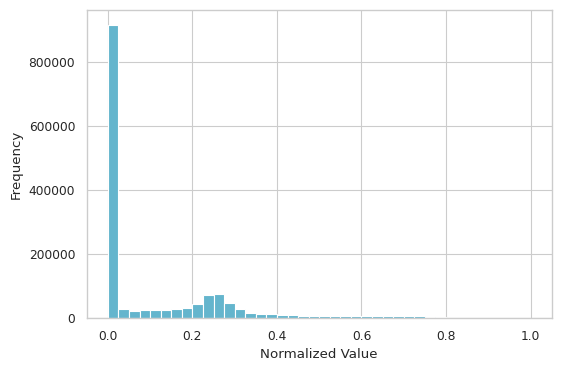

In [ ]:
# plotting histogram
plt.figure(figsize=(6,4))
plt.hist(normalize(dcm_array).flatten(), bins=40, color='c')
plt.xlabel("Normalized Value")
plt.ylabel("Frequency")
plt.show()

## Input Pipeline

### Using tf.keras.utils.Sequence
Creating custom data generator using tf.keras.utils.Sequence when we don't want to load the entire dataset at once.

`Applying data generator to preprocessed data`:

In [ ]:
# Folder "normal" consists of normal samples(directories)
normal_dcm_paths = [
    os.path.join(os.getcwd(), "drive/MyDrive/Projects/MRI/mri_data/DICOM_Data/normal", x)
    for x in os.listdir("drive/MyDrive/Projects/MRI/mri_data/DICOM_Data/normal")]

# Folder "abnormal" consists of abnormal samples(directories)
abnormal_dcm_paths = [
    os.path.join(os.getcwd(), "drive/MyDrive/Projects/MRI/mri_data/DICOM_Data/abnormal", x)
    for x in os.listdir("drive/MyDrive/Projects/MRI/mri_data/DICOM_Data/abnormal")]

print("Number of normal brains: " + str(len(normal_dcm_paths)))
print("Number of abnormal brains: " + str(len(abnormal_dcm_paths)))

Number of normal brains: 2741
Number of abnormal brains: 391


In [ ]:
# checking shape of normal samples
for path in normal_dcm_paths:
  slices = load_scan(path)
  array = get_pixels(slices)
  print(array.shape)

In [ ]:
def load_scan(path):
    slices = [pydicom.dcmread(path + '/' + s) for s in os.listdir(path)]
    slices.sort(key = lambda x: int(x.InstanceNumber))
    return slices

def get_pixels(scans):
    """Combining the pixel arrays of multiple DICOM images into a single NumPy array """
    image = np.stack([s.pixel_array for s in scans])
    image = image.astype(np.int16)
    return image

def center_crop(image, width, height):
    """Center crop of image"""
    if (image.shape[1] < height) or (image.shape[2] < width):
            arr = np.squeeze(tf.image.resize_with_pad(np.expand_dims(image, axis=-1), height, width))
    else:
            arr = image

    y = arr.shape[1]
    x = arr.shape[2]
    startx = x//2 - (width//2)
    starty = y//2 - (height//2)
    cropped_image = arr[:, starty:starty+height, startx:startx+width]
    return cropped_image

def normalize(array):
    # normalized_array = array / array.max()
    # Min-Max normalization

    #epsilon = 1e-7  # small constant to avoid division by zero
    normalized_array = (array - array.min() ) / (array.max() - array.min())
    normalized_array = normalized_array.astype("float32")
    return normalized_array


# def resize_array(img):
#    img = ndimage.zoom(img, (0.4, 0.4, 1), order=1)
#    return img


def process_scan(path):
    """Read, combine, crop and normalize array"""

    # read DICOM images
    slices = load_scan(path)

    # combining MRI slices into a 3D array volume
    array = get_pixels(slices)

    # Center Crop
    array = center_crop(array, width=256, height=256)

    # Normalize
    array = normalize(array)

    # resize
    #array = resize_array(array)

    # clipping the array to have 16 slices
    if len(array) == 16:
      return array
    elif len(array) > 16:
            remainder = len(array) - 16
            array = array[int(remainder / 2): 16 + int(remainder / 2)]
            return array
    else:
      return

In [ ]:
# for example
path = '/content/drive/MyDrive/Projects/MRI/mri_data/DICOM_Data/normal/1.3.46.670589.11.10042.5.0.5244.2024011512084014448'
array = process_scan(path)
print(type(array))
print(array.shape)

<class 'numpy.ndarray'>
(16, 256, 256)


- **Saving NumPy Arrays to .npy Files**

In [ ]:
#### !rm -rf /content/DICOM_Data
#### !rm -rf /content/splitted_data

In [ ]:
# creating 'NPY_Data' folder
os.mkdir('/content/drive/MyDrive/Projects/MRI/mri_data/NPY_Data')
# creating 2 folders in 'NPY_Data' folder: one for normal and another for abnormal class
os.mkdir('/content/drive/MyDrive/Projects/MRI/mri_data/NPY_Data/normal')
os.mkdir('/content/drive/MyDrive/Projects/MRI/mri_data/NPY_Data/abnormal')

**Method 1:** Undersampling the majority class

 abnorml samples

In [ ]:
# array of arrays
abnormal_images = np.array([process_scan(path) for path in abnormal_dcm_paths])
print(abnormal_images.shape)

# transfering abnormal arrays to folder abnormal
for i in range(abnormal_images.shape[0]):
  data = abnormal_images[i]
  np.save(f'/content/drive/MyDrive/Projects/MRI/mri_data/NPY_Data/abnormal/abnormal_f{i}.npy', data)

# now, we have data on disk. Thus:
# we can free up memory by deleting variables that are not needed any more
del abnormal_images

# restart runtime to free up RAM

(391, 16, 256, 256)


first part of normal samples

In [ ]:
# array of arrays
normal_images = np.array([process_scan(path) for path in normal_dcm_paths[0:900] if process_scan(path) is not None])
print(normal_images.shape)

# transfering normal arrays to folder normal
for i in range(normal_images.shape[0]):
  data = normal_images[i]
  np.save(f'/content/drive/MyDrive/Projects/MRI/mri_data/NPY_Data/normal/normal_f{i}.npy', data)

del normal_images

(898, 16, 256, 256)


In [ ]:
# checking number of samples
print(len(os.listdir('/content/drive/MyDrive/Projects/MRI/mri_data/NPY_Data/abnormal')))
print(len(os.listdir('/content/drive/MyDrive/Projects/MRI/mri_data/NPY_Data/normal')))

391
898


- Splitting NPY_Data folder(that contains 2 subfolders: normal and abnormal) to 2 folders train and validation such that each of these also includes 2 subfolders: normal and abnormal

In [ ]:
# 80% for train and 20% for development
DATA_DIRECT = '/content/drive/MyDrive/Projects/MRI/mri_data/NPY_Data'
output_dir = '/content/drive/MyDrive/Projects/MRI/mri_data/splitted_data'
splitfolders.ratio(DATA_DIRECT, output=output_dir, seed=29, ratio=(0.8, 0.2, 0),
                   group_prefix=None, move=True)

Copying files: 1289 files [00:06, 186.82 files/s]


In [ ]:
print(os.listdir('/content/drive/MyDrive/Projects/MRI/mri_data/splitted_data'))
print(os.listdir('/content/drive/MyDrive/Projects/MRI/mri_data/splitted_data/train'))
print(os.listdir('/content/drive/MyDrive/Projects/MRI/mri_data/splitted_data/val'))
print(os.listdir('/content/drive/MyDrive/Projects/MRI/mri_data/splitted_data/test'))

['train', 'val', 'test']
['normal', 'abnormal']
['normal', 'abnormal']
['normal', 'abnormal']


In [ ]:
# class-imbalanced dataset: ---> train, validation and test sets should have same data distribution
print('Total training normal images :', len(os.listdir('/content/drive/MyDrive/Projects/MRI/mri_data/splitted_data/train/normal')))
print('Total training abnormal images :', len(os.listdir('/content/drive/MyDrive/Projects/MRI/mri_data/splitted_data/train/abnormal')))

print('Total validation normal images :', len(os.listdir('/content/drive/MyDrive/Projects/MRI/mri_data/splitted_data/val/normal')))
print('Total validation abnormal images :', len(os.listdir('/content/drive/MyDrive/Projects/MRI/mri_data/splitted_data/val/abnormal')))

print('Total test normal images :', len(os.listdir('/content/drive/MyDrive/Projects/MRI/mri_data/splitted_data/test/normal')))
print('Total test abnormal images :', len(os.listdir('/content/drive/MyDrive/Projects/MRI/mri_data/splitted_data/test/abnormal')))

Total training normal images : 718
Total training abnormal images : 312
Total validation normal images : 179
Total validation abnormal images : 78
Total test normal images : 1
Total test abnormal images : 1


In [ ]:
!mv /content/drive/MyDrive/Projects/MRI/mri_data/splitted_data/test/abnormal/abnormal_f350.npy /content/drive/MyDrive/Projects/MRI/mri_data/splitted_data/val/abnormal

In [ ]:
!mv /content/drive/MyDrive/Projects/MRI/mri_data/splitted_data/test/normal/normal_f603.npy  /content/drive/MyDrive/Projects/MRI/mri_data/splitted_data/val/normal

In [ ]:
# class-imbalanced dataset: ---> train, validation and test sets should have same data distribution
print('Total training normal images :', len(os.listdir('/content/drive/MyDrive/Projects/MRI/mri_data/splitted_data/train/normal')))
print('Total training abnormal images :', len(os.listdir('/content/drive/MyDrive/Projects/MRI/mri_data/splitted_data/train/abnormal')))

print('Total validation normal images :', len(os.listdir('/content/drive/MyDrive/Projects/MRI/mri_data/splitted_data/val/normal')))
print('Total validation abnormal images :', len(os.listdir('/content/drive/MyDrive/Projects/MRI/mri_data/splitted_data/val/abnormal')))

print('Total test normal images :', len(os.listdir('/content/drive/MyDrive/Projects/MRI/mri_data/splitted_data/test/normal')))
print('Total test abnormal images :', len(os.listdir('/content/drive/MyDrive/Projects/MRI/mri_data/splitted_data/test/abnormal')))

Total training normal images : 718
Total training abnormal images : 312
Total validation normal images : 180
Total validation abnormal images : 79
Total test normal images : 0
Total test abnormal images : 0


- Reading the paths of the dcm files from the class directories and then creating a dictionary that contains keys: train and validation.

In [7]:
# training paths
train_normal_paths = [
    os.path.join(os.getcwd(), "/content/drive/MyDrive/Projects/MRI/mri_data/splitted_data/train/normal", x)
    for x in os.listdir("/content/drive/MyDrive/Projects/MRI/mri_data/splitted_data/train/normal")]

train_abnormal_paths = [
    os.path.join(os.getcwd(), "/content/drive/MyDrive/Projects/MRI/mri_data/splitted_data/train/abnormal", x)
    for x in os.listdir("/content/drive/MyDrive/Projects/MRI/mri_data/splitted_data/train/abnormal")]

# merging two lists: train_normal_paths and train_abnormal_paths using + operator
train_paths = train_normal_paths + train_abnormal_paths
print(len(train_paths))


# validation paths
validation_normal_paths = [
    os.path.join(os.getcwd(), "/content/drive/MyDrive/Projects/MRI/mri_data/splitted_data/val/normal", x)
    for x in os.listdir("/content/drive/MyDrive/Projects/MRI/mri_data/splitted_data/val/normal")]

validation_abnormal_paths = [
    os.path.join(os.getcwd(), "/content/drive/MyDrive/Projects/MRI/mri_data/splitted_data/val/abnormal", x)
    for x in os.listdir("/content/drive/MyDrive/Projects/MRI/mri_data/splitted_data/val/abnormal")]

# merging two lists: validation_normal_paths and validation_abnormal_paths using + operator
validation_paths = validation_normal_paths + validation_abnormal_paths
print(len(validation_paths))

1030
259


In [ ]:
validation_abnormal_paths

['/content/drive/MyDrive/Projects/MRI/mri_data/splitted_data/val/abnormal/abnormal_f2.npy',
 '/content/drive/MyDrive/Projects/MRI/mri_data/splitted_data/val/abnormal/abnormal_f6.npy',
 '/content/drive/MyDrive/Projects/MRI/mri_data/splitted_data/val/abnormal/abnormal_f9.npy',
 '/content/drive/MyDrive/Projects/MRI/mri_data/splitted_data/val/abnormal/abnormal_f13.npy',
 '/content/drive/MyDrive/Projects/MRI/mri_data/splitted_data/val/abnormal/abnormal_f17.npy',
 '/content/drive/MyDrive/Projects/MRI/mri_data/splitted_data/val/abnormal/abnormal_f22.npy',
 '/content/drive/MyDrive/Projects/MRI/mri_data/splitted_data/val/abnormal/abnormal_f24.npy',
 '/content/drive/MyDrive/Projects/MRI/mri_data/splitted_data/val/abnormal/abnormal_f25.npy',
 '/content/drive/MyDrive/Projects/MRI/mri_data/splitted_data/val/abnormal/abnormal_f28.npy',
 '/content/drive/MyDrive/Projects/MRI/mri_data/splitted_data/val/abnormal/abnormal_f29.npy',
 '/content/drive/MyDrive/Projects/MRI/mri_data/splitted_data/val/abnormal

In [8]:
partition = {'train': train_paths, 'validation': validation_paths}

In [9]:
# creating a custom data generator that inherits from tf.keras.utils.Sequence class
class DICOMDataGenerator(tf.keras.utils.Sequence):
    'Generates data for Keras'
    def __init__(self, list_paths, batch_size=8, n_slices=16, height=256, width=256,
                 mode='fit', label_mode='binary',
                 n_classes=2, shuffle=True, random_state=1):
        'Initialization'
        self.batch_size = batch_size
        self.list_paths = list_paths
        self.n_slices = n_slices
        self.height = height
        self.width = width
        self.n_classes = n_classes
        self.shuffle = shuffle
        self.mode = mode
        self.random_state = random_state
        self.label_mode = label_mode

        self.on_epoch_end()

    def __len__(self):
        # this helps the data generator know when to stop.
        'Denotes the number of batches per epoch, so that the model sees the training samples at most once per epoch.'
        return int(np.floor(len(self.list_paths) / self.batch_size))

    def __getitem__(self, index):
        'Generate one batch of data'
        # Generate indexes of the batch
        indexes = self.indexes[index*self.batch_size:(index+1)*self.batch_size]

        # Find list of paths
        list_paths_batch = [self.list_paths[k] for k in indexes]

         # Generate data
        X = self.__generate_X(list_paths_batch)

        if self.mode == 'fit':
            y = self.__generate_y(list_paths_batch)
            return X, y

        elif self.mode == 'predict':
            return X

        else:
            raise AttributeError('The mode parameter should be set to "fit" or "predict".')

    def on_epoch_end(self):
        'Updates indexes after each epoch'
        self.indexes = np.arange(len(self.list_paths))
        if self.shuffle == True:
            np.random.seed(self.random_state)
            np.random.shuffle(self.indexes)


    def __generate_X(self, list_paths_batch):
        'Generates data containing batch_size samples'
        # X : (n_samples, n_slices, height, width)
        # Initialization
        X = np.empty((self.batch_size, self.n_slices, self.height, self.width))

        # Generate data
        for i, path in enumerate(list_paths_batch):
            # read image
            array = np.load(path)
            # Store sample
            X[i,] = array

        return X

    def __generate_y(self, list_paths_batch):
        # Initialization
        y = np.empty((self.batch_size), dtype=np.int8)

        for i, path in enumerate(list_paths_batch):
            # store class
            if 'abnormal' in path:
              y[i] = 1
            else:
              y[i] = 0

        if self.label_mode == 'binary':
            return y

        elif self.label_mode == 'categorical':
            return tf.keras.utils.to_categorical(y, num_classes=self.n_classes)

        else:
            raise AttributeError('The label_mode parameter should be set to "binary" or "categorical".')


In [10]:
# Defining data loaders(data generators):
BATCH_SIZE = 8

train_loader = DICOMDataGenerator(partition['train'], batch_size=BATCH_SIZE, n_slices=16, height=256, width=256,
                                   label_mode='binary', n_classes=2,
                                   shuffle=True, mode='fit', random_state=1)

validation_loader = DICOMDataGenerator(partition['validation'], batch_size=BATCH_SIZE, n_slices=16, height=256, width=256,
                                       label_mode='binary', n_classes=2,
                                       shuffle=True, mode='fit', random_state=1)


# checking data type of data generatros; for example: train_loader
print(type(train_loader))

for image_batch, labels_batch in train_loader:
   print(f'Image Batch Shape = {image_batch.shape}')
   print('min=%.3f, max=%.3f' % (image_batch.min(), image_batch.max()))
   print(type(image_batch))
   print(image_batch.dtype)

   print('-----'*5)

   print(f'Labels Batch Shape = {labels_batch.shape}')
   print('min=%.3f, max=%.3f' % (labels_batch.min(), labels_batch.max()))
   print(type(labels_batch))
   print(labels_batch.dtype)
   print(labels_batch)
   break

<class '__main__.DICOMDataGenerator'>
Image Batch Shape = (8, 16, 256, 256)
min=0.000, max=1.000
<class 'numpy.ndarray'>
float64
-------------------------
Labels Batch Shape = (8,)
min=0.000, max=1.000
<class 'numpy.ndarray'>
int8
[0 0 1 0 1 0 0 0]


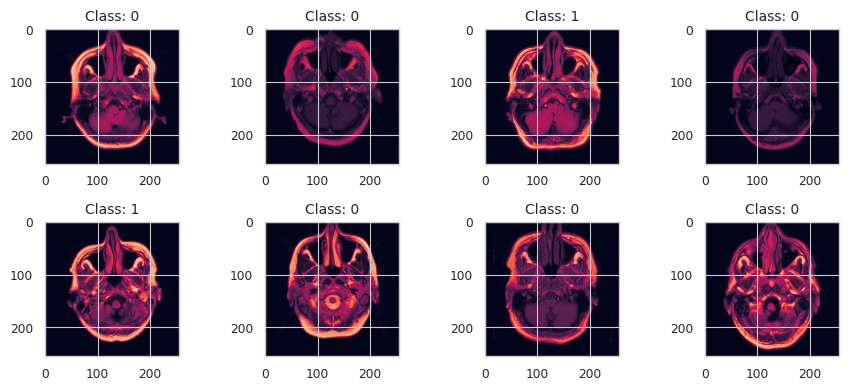

In [ ]:
# visualizing several samples from one batch
plt.figure(figsize=(9, 4))
for i in range(0, 8):
    plt.subplot(2, 4, i+1)
    for X_batch, y_batch in train_loader:
        # visualizing 16th slice for different samples from one batch
        image = X_batch[i, 15, :, :]
        plt.imshow(image)
        plt.title(f"Class: {y_batch[i]}", fontsize=10)
        break
plt.tight_layout()
plt.show()

In [ ]:
# for example
X_batch[0, 15, 100:150, 100:150]

array([[0.2676923 , 0.25538462, 0.18153846, ..., 0.32307693, 0.44307691,
        0.56      ],
       [0.23384616, 0.20923077, 0.16923077, ..., 0.34461537, 0.46461537,
        0.52615386],
       [0.23692308, 0.21230769, 0.19076923, ..., 0.39384615, 0.44923076,
        0.42769229],
       ...,
       [0.07384615, 0.05538461, 0.04923077, ..., 0.11384615, 0.11076923,
        0.16      ],
       [0.10153846, 0.06461538, 0.06153846, ..., 0.14461538, 0.16615385,
        0.17846154],
       [0.12307692, 0.09538461, 0.07692308, ..., 0.14461538, 0.15692307,
        0.16615385]])

## Model: CNN

In [11]:
# Building model
def build_model(n_slices, height, width):
    inputs = tf.keras.Input((n_slices, height, width, 1))

    x = layers.Conv3D(filters=64, kernel_size=3, padding='same', activation="relu")(inputs)
    x = layers.MaxPool3D(pool_size=2)(x)
    x = layers.BatchNormalization()(x)

    x = layers.Conv3D(filters=64, kernel_size=3, padding='same', activation="relu")(x)
    x = layers.MaxPool3D(pool_size=2)(x)
    x = layers.BatchNormalization()(x)

    x = layers.Conv3D(filters=128, kernel_size=3, padding='same', activation="relu")(x)
    x = layers.MaxPool3D(pool_size=2)(x)
    x = layers.BatchNormalization()(x)

    x = layers.Conv3D(filters=256, kernel_size=3, padding='same', activation="relu")(x)
    x = layers.MaxPool3D(pool_size=2)(x)
    x = layers.BatchNormalization()(x)

    x = layers.GlobalAveragePooling3D()(x)
    x = layers.Dense(units=512, activation="relu")(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(units=1, activation="sigmoid")(x)
    model = tf.keras.Model(inputs, outputs)

    return model


n_slices = 16
height = 256
width = 256

model = build_model(n_slices, height, width)
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 16, 256, 256, 1   0         
                             )]                                  
                                                                 
 conv3d (Conv3D)             (None, 16, 256, 256, 64   1792      
                             )                                   
                                                                 
 max_pooling3d (MaxPooling3  (None, 8, 128, 128, 64)   0         
 D)                                                              
                                                                 
 batch_normalization (Batch  (None, 8, 128, 128, 64)   256       
 Normalization)                                                  
                                                                 
 conv3d_1 (Conv3D)           (None, 8, 128, 128, 64)   110656

 Compile

- CPU/GPU

In [12]:
#metrics = [keras.metrics.SensitivityAtSpecificity(0.95),
  #  keras.metrics.SpecificityAtSensitivity(0.95),
  #  keras.metrics.AUC(name='auc')]

# custom PR AUC metric
pr_auc = AUC(curve='PR', name='pr_auc')

loss = tf.keras.losses.BinaryCrossentropy()
optimizer = tf.keras.optimizers.Adam(0.001)

model.compile(loss=loss, metrics=['accuracy', 'AUC', pr_auc], optimizer=optimizer)

- **Saving best model**

In [13]:
# checkpoint
# Model is saved at the end of every epoch, if it's the best seen so far.

# for tensorflow 2.17:
# filepath = "/content/drive/MyDrive/Projects/MRI/model/checkpoint.model.keras"

# for tensorflow 2.15:
filepath = "/content/drive/MyDrive/Projects/MRI/model/model.best.h5"

# ModelCheckpoint to save the best model based on PR AUC
checkpoint = ModelCheckpoint(filepath, monitor='val_pr_auc',
                             verbose=1, save_best_only=True, mode='max')

# Early Stopping based on PR AUC
es = EarlyStopping(monitor='val_pr_auc', patience=30, mode='max', restore_best_weights=True)
# # Combining callbacks
callbacks_list = [checkpoint, es]

### Train

In [14]:
history = model.fit(train_loader, validation_data=validation_loader, epochs=150,
                    callbacks=callbacks_list, verbose=1)

Epoch 1/150
128/128 [==============================] - ETA: 0s - loss: 0.6569 - accuracy: 0.6777 - auc: 0.5087 - pr_auc: 0.3146
Epoch 1: val_pr_auc improved from -inf to 0.30545, saving model to /content/drive/MyDrive/Projects/MRI/model/model.best.h5


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


128/128 [==============================] - 400s 3s/step - loss: 0.6569 - accuracy: 0.6777 - auc: 0.5087 - pr_auc: 0.3146 - val_loss: 3.8203 - val_accuracy: 0.3047 - val_auc: 0.5018 - val_pr_auc: 0.3055
Epoch 2/150
128/128 [==============================] - ETA: 0s - loss: 0.6136 - accuracy: 0.6943 - auc: 0.5955 - pr_auc: 0.3899
Epoch 2: val_pr_auc did not improve from 0.30545
128/128 [==============================] - 89s 691ms/step - loss: 0.6136 - accuracy: 0.6943 - auc: 0.5955 - pr_auc: 0.3899 - val_loss: 2.3999 - val_accuracy: 0.3047 - val_auc: 0.4848 - val_pr_auc: 0.2922
Epoch 3/150
128/128 [==============================] - ETA: 0s - loss: 0.6127 - accuracy: 0.6855 - auc: 0.5993 - pr_auc: 0.3881
Epoch 3: val_pr_auc improved from 0.30545 to 0.36491, saving model to /content/drive/MyDrive/Projects/MRI/model/model.best.h5
128/128 [==============================] - 91s 705ms/step - loss: 0.6127 - accuracy: 0.6855 - auc: 0.5993 - pr_auc: 0.3881 - val_loss: 1.0115 - val_accuracy: 0.304

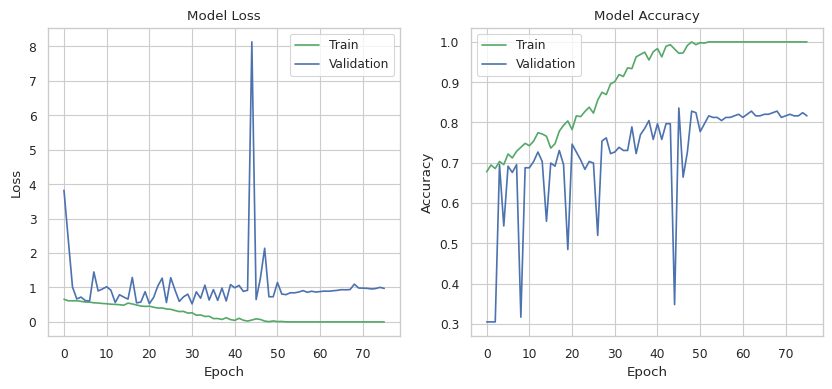

In [15]:
# plotting loss
#plt.style.use("ggplot")
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], 'g')
plt.plot(history.history['val_loss'], 'b')
plt.legend(["Train", "Validation"])
plt.title(f"Model Loss")
plt.ylabel('Loss')
plt.xlabel('Epoch')

# plotting accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], 'g')
plt.plot(history.history['val_accuracy'], 'b')
plt.legend(["Train", "Validation"])
plt.title(f"Model Accuracy")
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.show()

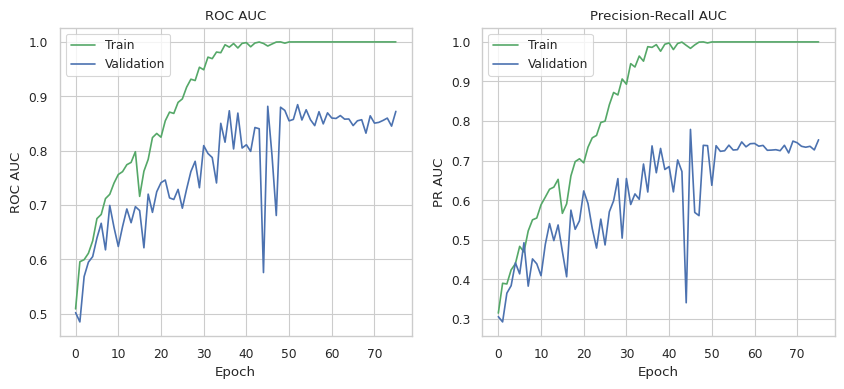

In [16]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['auc'], 'g')
plt.plot(history.history['val_auc'], 'b')
plt.legend(["Train", "Validation"])
plt.title("ROC AUC")
plt.ylabel('ROC AUC')
plt.xlabel('Epoch')

plt.subplot(1, 2, 2)
plt.plot(history.history['pr_auc'], 'g')
plt.plot(history.history['val_pr_auc'], 'b')
plt.legend(["Train", "Validation"])
plt.title("Precision-Recall AUC")
plt.ylabel('PR AUC')
plt.xlabel('Epoch')

plt.show()

### Evaluation

In [17]:
filepath = "/content/drive/MyDrive/Projects/MRI/model/model.best.h5"
# The model (that are considered the best) can be loaded as
loaded_model = tf.keras.models.load_model(filepath)

# compile model (required to make predictions)
optimizer = tf.keras.optimizers.Adam(0.001)
loss = tf.keras.losses.BinaryCrossentropy()

loaded_model.compile(loss=loss, metrics=['accuracy', 'AUC', pr_auc], optimizer=optimizer)

loss, accuracy, AUC, pr_auc = loaded_model.evaluate(validation_loader)
print('Val. loss :', loss)
print('Val. accuracy :', accuracy)
print('Val. ROC-AUC :', AUC)
print('Val. PR-AUC :', pr_auc)

32/32 [==============================] - 8s 232ms/step - loss: 0.6482 - accuracy: 0.8359 - auc: 0.8816 - pr_auc: 0.7596
Val. loss : 0.6481548547744751
Val. accuracy : 0.8359375
Val. ROC-AUC : 0.8815543055534363
Val. PR-AUC : 0.7595962285995483


## Submission

In [18]:
def predict(series_path, csv_path):
    loaded_model = tf.keras.models.load_model("/content/drive/MyDrive/Projects/MRI/model/model.best.h5")


    series_list = os.listdir(series_path)
    probabilities = {"SeriesInstanceUID": [], "prediction": []}

    for s in series_list:
        slices = [pydicom.dcmread(os.path.join(series_path, s, dcm)) for dcm in os.listdir(os.path.join(series_path, s))]
        slices.sort(key = lambda x: int(x.InstanceNumber))

        image = np.stack([slice.pixel_array for slice in slices])
        image = image.astype(np.int16)

        width=256
        height=256
        if (image.shape[1] < height) or (image.shape[2] < width):
            arr = np.squeeze(tf.image.resize_with_pad(np.expand_dims(image, axis=-1), height, width))
        else:
            arr = image

        y = arr.shape[1]
        x = arr.shape[2]
        startx = x//2 - (width//2)
        starty = y//2 - (height//2)
        cropped_image = arr[:, starty:starty+height, startx:startx+width]

        normalized_array = (cropped_image - cropped_image.min()) / (cropped_image.max() - cropped_image.min())
        normalized_array = normalized_array.astype("float32")


        if len(normalized_array) == 16:
             image = normalized_array

        elif len(normalized_array) > 16:
            remainder = len(normalized_array) - 16
            image = normalized_array[int(remainder / 2): 16 + int(remainder / 2)]


        pred = loaded_model.predict(np.expand_dims(image, axis=(0, -1)))
        # pred = loaded_model.predict(np.expand_dims(image, axis=0))
        probability = pred[0][0]
        probabilities["SeriesInstanceUID"].append(s)
        probabilities["prediction"].append(probability)

    df = pd.DataFrame(probabilities)
    df.to_csv(csv_path, index=False)


In [19]:
predict('/content/drive/MyDrive/Projects/MRI/mri_data/data-dir', 'submission.csv')

1/1 [==============================] - 0s 20ms/step
